In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots look nice
plt.style.use('ggplot')

# 1. Load the data
print("Loading data...")
train_df = pd.read_csv('../data/train.csv')
features_df = pd.read_csv('../data/features.csv')
stores_df = pd.read_csv('../data/stores.csv')

# 2. Merge everything into one master table
merged_df = pd.merge(train_df, stores_df, on='Store', how='left')
df = pd.merge(merged_df, features_df, on=['Store', 'Date', 'IsHoliday'], how='left')

# 3. Clean the dates and missing markdowns (promotions)
df['Date'] = pd.to_datetime(df['Date'])
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

print(f"Data successfully merged! Total rows: {len(df)}")
display(df.head()) # This will show you the first 5 rows of your data

Loading data...
Data successfully merged! Total rows: 421570


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106


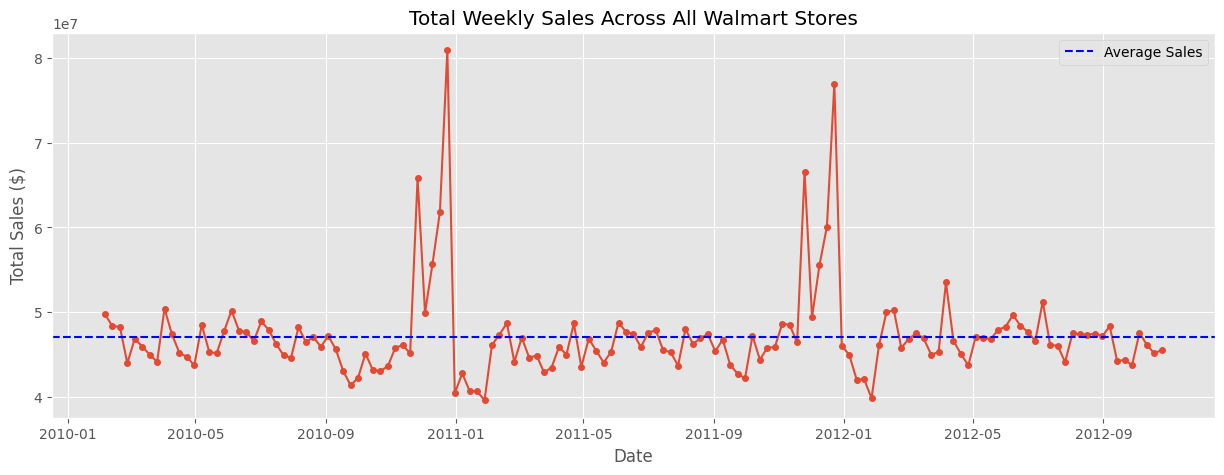

In [2]:
# Group sales by Date to see the overall trend across all stores
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(15, 5))
plt.plot(weekly_sales.index, weekly_sales.values, marker='o', linestyle='-', markersize=4)
plt.title('Total Weekly Sales Across All Walmart Stores')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.axhline(weekly_sales.mean(), color='blue', linestyle='--', label='Average Sales')
plt.legend()
plt.show()

In [3]:
# Extract numbers from the Date
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Convert True/False 'IsHoliday' into 1 and 0
df['IsHoliday'] = df['IsHoliday'].astype(int)

# Define which columns the model is allowed to look at to make its prediction
features = ['Store', 'Dept', 'IsHoliday', 'Temperature', 'CPI', 'Unemployment', 'Week', 'Month', 'Year']
features += ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Clean up any remaining missing rows just for this quick baseline
model_data = df.dropna(subset=features + ['Weekly_Sales'])

# X = What the model looks at (Features)
# y = What the model tries to predict (Target: Sales)
X = model_data[features]
y = model_data['Weekly_Sales']

print(f"Features ready! We have {len(X)} rows of data prepared for the model.")

Features ready! We have 421570 rows of data prepared for the model.


In [9]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split data: 80% for training, 20% for testing to see how good it is
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training the XGBoost model... (This usually takes 2 to 5 seconds)")
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Ask the model to predict sales for the 20% of data it hasn't seen
predictions = model.predict(X_test)

# Calculate how far off the predictions are on average
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("\n--- Baseline Model Performance ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print("----------------------------------")
print("Success! You have just trained your first dynamic pricing demand model.")

Training the XGBoost model... (This usually takes 2 to 5 seconds)

--- Baseline Model Performance ---
Mean Absolute Error (MAE): $5,131.01
Root Mean Squared Error (RMSE): $8,777.29
----------------------------------
Success! You have just trained your first dynamic pricing demand model.


In [10]:
import mlflow
import mlflow.xgboost

# 1. Create an experiment name in MLflow
mlflow.set_experiment("DynaPrice_Demand_Forecasting")

# 2. Start tracking!
with mlflow.start_run(run_name="Baseline_XGBoost"):
    
    # Log the parameters we used for the model
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    
    # Log the performance scores we just calculated
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    
    # Save the actual model file into MLflow
    mlflow.xgboost.log_model(model, "xgboost_model")
    
    print("Experiment successfully tracked in MLflow! 🎉")

2026/06/25 14:51:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/25 14:51:11 INFO mlflow.store.db.utils: Updating database tables
2026/06/25 14:51:12 INFO mlflow.tracking.fluent: Experiment with name 'DynaPrice_Demand_Forecasting' does not exist. Creating a new experiment.
2026/06/25 14:51:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Experiment successfully tracked in MLflow! 🎉
